In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import warnings
from matplotlib.ticker import ScalarFormatter
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.linewidth': 0.8,

    # "text.usetex": True,
    # "font.family": "serif",
    # "font.serif": ["Computer Modern Roman"],
    # "axes.unicode_minus": False
})

In [28]:
def hill_activator(concentration, rho, beta, kd, n):
    hill_term = (concentration ** n) / (kd ** n + concentration ** n)
    return rho * (beta + (1 - beta) * hill_term)

def hill_repressor(concentration, rho, beta, kd, n):
    hill_term = (concentration ** n) / (kd ** n + concentration ** n)
    return rho * (beta + (1 - beta) * (1 - hill_term))

def get_stats_original(df, construct_name, norm_method='max_norm'):
    cols = [c for c in df.columns if str(c).startswith(construct_name) and
            (len(str(c)) == len(construct_name) or str(c)[len(construct_name)] == '.')]
    if not cols: return None, None

    data = df[cols].values.astype(float)
    means = np.nanmean(data, axis=1)
    n_valid = np.sum(~np.isnan(data), axis=1)

    std_errors = np.zeros_like(means)
    for i in range(len(means)):
        if n_valid[i] > 1:
            std_errors[i] = np.nanstd(data[i, :], ddof=1) / np.sqrt(n_valid[i])
        elif n_valid[i] == 1:
            std_errors[i] = means[i] * 0.1
        else:
            std_errors[i] = np.nan

    if norm_method == 'max_norm':
        y_max = np.nanmax(means)
        if y_max > 0: means, std_errors = means / y_max, std_errors / y_max
    elif norm_method == 'min_max':
        valid_means = means[~np.isnan(means)]
        y_min, y_max = np.nanmin(valid_means), np.nanmax(valid_means)
        if y_max > y_min: means, std_errors = (means - y_min) / (y_max - y_min), std_errors / (y_max - y_min)

    return means, std_errors

def fit_hill_original(x, y, y_err, is_max_norm=False):
    mask = ~np.isnan(y) & ~np.isnan(y_err) & (x > 0)
    if np.sum(mask) < 3: return None

    x_data, y_data, y_errors = x[mask].values, y[mask], y_err[mask]

    idx = np.argsort(x_data)
    x_s, y_s = x_data[idx], y_data[idx]
    q1_mean = np.mean(y_s[:len(y_s)//4 + 1])
    q4_mean = np.mean(y_s[3*len(y_s)//4:])

    eq_type = 'activator' if q4_mean > q1_mean * 1.2 else 'repressor'
    hill_func = hill_activator if eq_type == 'activator' else hill_repressor

    y_min, y_max = np.min(y_data), np.max(y_data)
    half_resp = y_min + (y_max - y_min)/2 if eq_type == 'activator' else y_max - (y_max - y_min)/2
    kd_est = x_data[np.argmin(np.abs(y_data - half_resp))]
    beta_est = np.clip(y_min / y_max if y_max > 0 else 0.01, 0.001, 0.5)

    if is_max_norm:
        p0 = [beta_est, kd_est, 1.0]
        bounds = ([0.0, np.min(x_data)*0.01, 0.1], [1.0, np.max(x_data)*100, 10.0])
        def f_fit(x, b, k, n): return hill_func(x, 1.0, b, k, n)
    else:
        p0 = [y_max * 1.2, beta_est, kd_est, 1.0]
        bounds = ([0, 0.0, np.min(x_data)*0.01, 0.1], [np.inf, 1.0, np.max(x_data)*100, 10.0])
        f_fit = hill_func

    best_r2, best_res = -np.inf, None
    for attempt in range(3):
        try:
            p_try = p0.copy()
            if attempt == 1: p_try[1 if is_max_norm else 2] *= 0.1
            elif attempt == 2: p_try[1 if is_max_norm else 2] *= 10

            sigma_adj = np.maximum(y_errors, np.max(y_errors) * 0.1)
            popt, pcov = curve_fit(f_fit, x_data, y_data, p0=p_try, sigma=sigma_adj, bounds=bounds, method='trf', maxfev=5000)

            y_pred = f_fit(x_data, *popt)
            ss_res = np.sum((y_data - y_pred)**2)
            ss_tot = np.sum((y_data - np.mean(y_data))**2)
            r2 = 1 - (ss_res/ss_tot) if ss_tot > 0 else 0

            if r2 > best_r2:
                best_r2 = r2
                perr = np.sqrt(np.diag(pcov))
                if is_max_norm:
                    best_res = ({'rho': 1.0, 'beta': popt[0], 'kd': popt[1], 'n': popt[2]},
                                {'rho': 0.0, 'beta': perr[0], 'kd': perr[1], 'n': perr[2]})
                else:
                    best_res = ({'rho': popt[0], 'beta': popt[1], 'kd': popt[2], 'n': popt[3]},
                                {'rho': perr[0], 'beta': perr[1], 'kd': perr[2], 'n': perr[3]})
        except: continue

    if best_res is None: return None
    return eq_type, best_res[0], best_res[1], best_r2

def calc_ec(params, eq_type, target):
    kd, n = params['kd'], params['n']
    return kd * (target / (1 - target))**(1/n) if eq_type == 'activator' else kd * ((1 - target) / target)**(1/n)

def calc_lod(params, sigma_blank):

    rho, beta, kd, n = params['rho'], params['beta'], params['kd'], params['n']

    if kd > 0 and not np.isnan(rho) and not np.isnan(beta) and not np.isnan(n):
        max_slope_linear = abs((rho * n * (1 - beta)) / (4 * kd))

        if max_slope_linear > 0 and sigma_blank > 0:
            return 3 * sigma_blank / max_slope_linear

    return np.nan

In [50]:
fontsize=15
FILE = "FACS_summary.xlsx"
SHEET = "Heme"
LOG_Y = True
NORM_METHOD = 'none' # 'max_norm', 'min_max', 'none'
CONSTRUCTS = ["HD1", "HD2", "HD3","HD4"] #["BD1", "BD2", "BD3", "BD4" ] #["HD1", "HD2", "HD3"]
DO_FIT = True
USE_SCIENTIFIC_NOTATION = True

df = pd.read_excel(FILE, sheet_name=SHEET)
conc_col = df.columns[1]
x_data = df[conc_col]
df = pd.read_excel(FILE, sheet_name=SHEET)

conc = conc_col.split('[')[1].split(']')[0]

print(f"Loaded {SHEET}. Concentration: {conc_col}, Units: {conc}")

Loaded Heme. Concentration: Heme concentration [uM], Units: uM


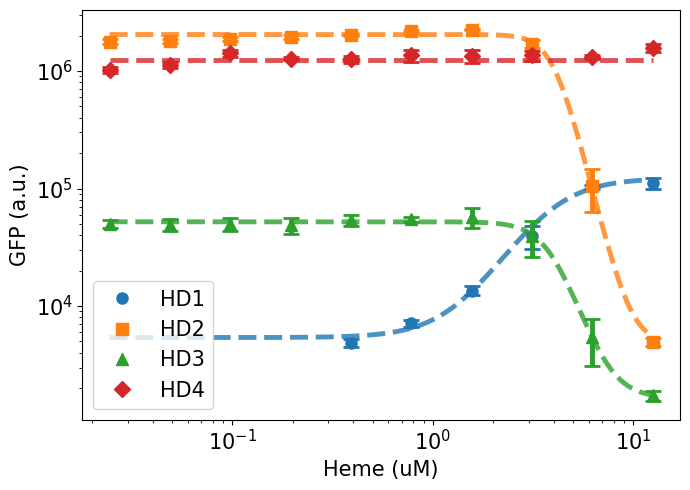

,Construct,Type,On/Off Ratio,LOD,EC10,EC90,Kd,Hill (n),Beta,Rho,R2
0,HD1,Activator,32.36,0.03,1.80,7.99,3.79 ± 0.60,2.95 ± 0.49,0.044,122414.7,0.987
1,HD2,Repressor,454.87,0.47,5.54,2.95,4.04 ± 0.70,6.98 ± 3.33,0.002,2040726.0,0.961
2,HD3,Repressor,32.98,0.74,5.88,2.60,3.91 ± 0.42,5.38 ± 1.37,0.032,52097.7,0.982
3,HD4,Repressor,1.93,5211.91,814.68,514.54,647.45 ± 0.00,9.56 ± 0.00,0.983,1240625.9,-0.185


In [52]:
fig, ax = plt.subplots(figsize=(7, 5))
results = []
markers= ['o', 's', '^', 'D', 'v', '<', '>', 'p']
for name,m in zip(CONSTRUCTS,markers):
    y_mean, y_sem = get_stats_original(df, name, norm_method=NORM_METHOD)
    if y_mean is None : continue

    # if name is not "HD4":
    line, = ax.plot(x_data, y_mean, marker=m,linestyle='', label=name, markersize=8)
    color = line.get_color()
    ax.errorbar(x_data, y_mean, yerr=y_sem, fmt='none', ecolor=color, capsize=6, alpha=1,linewidth=3.5,capthick=2)

    valid_y = y_mean[~np.isnan(y_mean)]
    on_off_ratio = np.max(valid_y) / np.min(valid_y) if np.min(valid_y) > 0 else np.inf

    blank_idx = np.argmin(x_data.values)
    sigma_blank = y_sem.iloc[blank_idx] if hasattr(y_sem, 'iloc') else y_sem[blank_idx]

    if DO_FIT:
        fit_res = fit_hill_original(x_data, y_mean, y_sem, is_max_norm=(NORM_METHOD == 'max_norm'))

        if fit_res:

            eq_type, params, errors, r2 = fit_res
            x_smooth = np.logspace(np.log10(x_data[x_data>0].min()), np.log10(x_data.max()), 200)
            hill_f = hill_activator if eq_type == 'activator' else hill_repressor
            y_smooth = hill_f(x_smooth, params['rho'], params['beta'], params['kd'], params['n'])
            # if name is not "HD4":
            ax.plot(x_smooth, y_smooth, '--', color=color, alpha=0.8,linewidth=3.5)
            lod_val = calc_lod(params, sigma_blank)
            results.append({
                'Construct': name,
                'Type': eq_type.capitalize(),
                'On/Off Ratio': f"{on_off_ratio:.2f}",
                'LOD': f"{lod_val:.2f}" if not np.isnan(lod_val) else "N/A",
                'EC10': round(calc_ec(params, eq_type, 0.1), 2),
                'EC90': round(calc_ec(params, eq_type, 0.9), 2),
                'Kd': f"{params['kd']:.2f} ± {errors['kd']:.2f}",
                'Hill (n)': f"{params['n']:.2f} ± {errors['n']:.2f}",
                'Beta': round(params['beta'], 3),
                'Rho': round(params['rho'], 1),
                'R2': round(r2, 3)
            })

if USE_SCIENTIFIC_NOTATION and NORM_METHOD=='none':
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_fontsize(fontsize)
ax.set_xscale('log')
if LOG_Y: ax.set_yscale('log')
ax.set_xlabel(f"{SHEET} ({conc})", fontsize=fontsize)
ax.set_ylabel(f"GFP (a.u.)", fontsize=fontsize)
ax.tick_params(axis='both', labelsize=fontsize)
ax.legend(fontsize=fontsize)
plt.tight_layout()
plt.savefig(f"biosensor_results/figures/{SHEET}_dose_response.png", dpi=600)
plt.show()

if DO_FIT and results:
    df_results = pd.DataFrame(results)
    display(df_results)
    df_results.to_csv(f"biosensor_results/csv/{SHEET}_final_stats.csv", index=False)

In [31]:
fontsize=15
FILE = "FACS_summary.xlsx"
SHEET = "Butyrate"
LOG_Y = False
NORM_METHOD = 'none' # 'max_norm', 'min_max', 'none'
CONSTRUCTS = ["BD1", "BD2", "BD3", "BD4" ]
DO_FIT = True
USE_SCIENTIFIC_NOTATION = True

df = pd.read_excel(FILE, sheet_name=SHEET)
conc_col = df.columns[1]
x_data = df[conc_col]
df = pd.read_excel(FILE, sheet_name=SHEET)

conc = conc_col.split('[')[1].split(']')[0]

print(f"Loaded {SHEET}. Concentration: {conc_col}, Units: {conc}")

Loaded Butyrate. Concentration: Butyrate concentration [mM], Units: mM


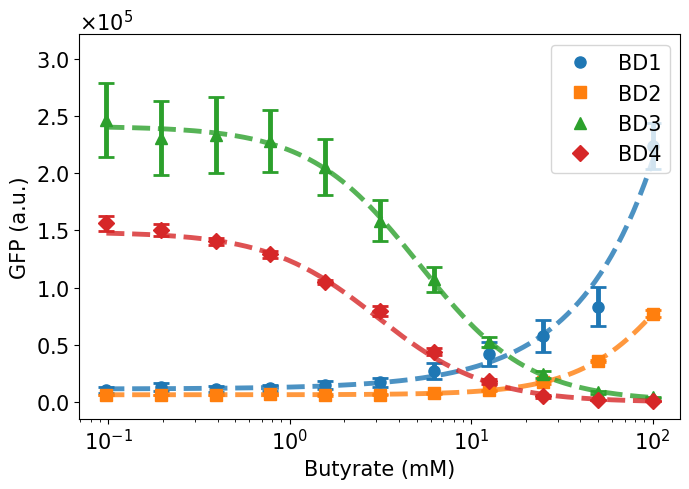

,Construct,Type,On/Off Ratio,LOD,EC10,EC90,Kd,Hill (n),Beta,Rho,R2
0,BD1,Activator,20.92,10.35,1203.84,83023.48,9997.35 ± 624893.58,1.04 ± 0.26,0.00048,23982170.4,0.977
1,BD2,Activator,14.28,0.98,40.07,645.23,160.79 ± 39.39,1.58 ± 0.07,0.02860,226359.3,1.000
2,BD3,Repressor,61.73,6.16,23.96,1.11,5.15 ± 0.20,1.43 ± 0.05,0.00265,241000.1,0.999
3,BD4,Repressor,128.70,0.56,14.02,0.66,3.03 ± 0.22,1.43 ± 0.10,0.00000,148661.8,0.996


In [33]:
fig, ax = plt.subplots(figsize=(7, 5))
results = []
markers= ['o', 's', '^', 'D', 'v', '<', '>', 'p']
for name,m in zip(CONSTRUCTS,markers):
    y_mean, y_sem = get_stats_original(df, name, norm_method=NORM_METHOD)
    if y_mean is None: continue


    line, = ax.plot(x_data, y_mean, marker=m,linestyle='', label=name, markersize=8)
    color = line.get_color()
    ax.errorbar(x_data, y_mean, yerr=y_sem, fmt='none', ecolor=color, capsize=6, alpha=1,linewidth=3.5,capthick=2)

    valid_y = y_mean[~np.isnan(y_mean)]
    on_off_ratio = np.max(valid_y) / np.min(valid_y) if np.min(valid_y) > 0 else np.inf

    blank_idx = np.argmin(x_data.values)
    sigma_blank = y_sem.iloc[blank_idx] if hasattr(y_sem, 'iloc') else y_sem[blank_idx]

    if DO_FIT:
        fit_res = fit_hill_original(x_data, y_mean, y_sem, is_max_norm=(NORM_METHOD == 'max_norm'))

        if fit_res:

            eq_type, params, errors, r2 = fit_res
            x_smooth = np.logspace(np.log10(x_data[x_data>0].min()), np.log10(x_data.max()), 200)
            hill_f = hill_activator if eq_type == 'activator' else hill_repressor
            y_smooth = hill_f(x_smooth, params['rho'], params['beta'], params['kd'], params['n'])

            ax.plot(x_smooth, y_smooth, '--', color=color, alpha=0.8,linewidth=3.5)
            lod_val = calc_lod(params, sigma_blank)
            results.append({
                'Construct': name,
                'Type': eq_type.capitalize(),
                'On/Off Ratio': f"{on_off_ratio:.2f}",
                'LOD': f"{lod_val:.2f}" if not np.isnan(lod_val) else "N/A",
                'EC10': round(calc_ec(params, eq_type, 0.1), 2),
                'EC90': round(calc_ec(params, eq_type, 0.9), 2),
                'Kd': f"{params['kd']:.2f} ± {errors['kd']:.2f}",
                'Hill (n)': f"{params['n']:.2f} ± {errors['n']:.2f}",
                'Beta': round(params['beta'], 5),
                'Rho': round(params['rho'], 1),
                'R2': round(r2, 3)
            })

if USE_SCIENTIFIC_NOTATION and NORM_METHOD=='none':
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Always use scientific notation
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_fontsize(fontsize)
ax.set_xscale('log')
if LOG_Y: ax.set_yscale('log')
ax.set_xlabel(f"{SHEET} ({conc})", fontsize=fontsize)
ax.set_ylabel(f"GFP (a.u.)", fontsize=fontsize)
ax.tick_params(axis='both', labelsize=fontsize)
ax.legend(fontsize=fontsize)
plt.tight_layout()
plt.savefig(f"biosensor_results/figures/{SHEET}_dose_response.png", dpi=600)
plt.show()

if DO_FIT and results:
    df_results = pd.DataFrame(results)
    display(df_results)
    df_results.to_csv(f"biosensor_results/csv/{SHEET}_final_stats.csv", index=False)

In [48]:
fontsize=15
FILE = "FACS_summary.xlsx"
SHEET = "Lactate"
LOG_Y = False
NORM_METHOD = 'none' # 'max_norm', 'min_max', 'none'
CONSTRUCTS = ["LD1", "LD2", "LD3", "LD4"]
DO_FIT = True
USE_SCIENTIFIC_NOTATION = True

df = pd.read_excel(FILE, sheet_name=SHEET)
conc_col = df.columns[1]
x_data = df[conc_col]
df = pd.read_excel(FILE, sheet_name=SHEET)

conc = conc_col.split('[')[1].split(']')[0]

print(f"Loaded {SHEET}. Concentration: {conc_col}, Units: {conc}")

Loaded Lactate. Concentration: Lactate concentration [mM], Units: mM


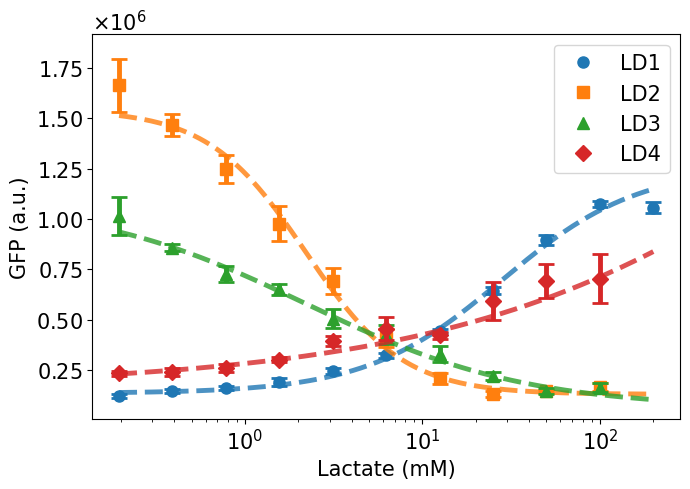

,Construct,Type,On/Off Ratio,LOD,EC10,EC90,Kd,Hill (n),Beta,Rho,R2
0,LD1,Activator,10.92,1.11,4.03,195.88,28.09 ± 5.49,1.13 ± 0.15,0.10555,1259423.8,0.992
1,LD2,Repressor,13.38,1.41,8.82,0.55,2.20 ± 0.43,1.58 ± 0.30,0.08295,1544677.9,0.989
2,LD3,Repressor,7.51,3.60,50.76,0.10,2.22 ± 0.94,0.70 ± 0.21,0.05417,1094890.1,0.986
3,LD4,Activator,3.10,1745.51,23.09,4330689.66,10000.00 ± 399732.66,0.36 ± 0.50,0.04477,3622410.0,0.927


In [49]:
fig, ax = plt.subplots(figsize=(7, 5))
results = []
markers= ['o', 's', '^', 'D', 'v', '<', '>', 'p']
for name,m in zip(CONSTRUCTS,markers):
    y_mean, y_sem = get_stats_original(df, name, norm_method=NORM_METHOD)
    if y_mean is None: continue


    line, = ax.plot(x_data, y_mean, marker=m,linestyle='', label=name, markersize=8)
    color = line.get_color()
    ax.errorbar(x_data, y_mean, yerr=y_sem, fmt='none', ecolor=color, capsize=6, alpha=1,linewidth=3.5,capthick=2)

    valid_y = y_mean[~np.isnan(y_mean)]
    on_off_ratio = np.max(valid_y) / np.min(valid_y) if np.min(valid_y) > 0 else np.inf

    blank_idx = np.argmin(x_data.values)
    sigma_blank = y_sem.iloc[blank_idx] if hasattr(y_sem, 'iloc') else y_sem[blank_idx]

    if DO_FIT:
        fit_res = fit_hill_original(x_data, y_mean, y_sem, is_max_norm=(NORM_METHOD == 'max_norm'))

        if fit_res:

            eq_type, params, errors, r2 = fit_res
            x_smooth = np.logspace(np.log10(x_data[x_data>0].min()), np.log10(x_data.max()), 200)
            hill_f = hill_activator if eq_type == 'activator' else hill_repressor
            y_smooth = hill_f(x_smooth, params['rho'], params['beta'], params['kd'], params['n'])

            ax.plot(x_smooth, y_smooth, '--', color=color, alpha=0.8,linewidth=3.5)
            lod_val = calc_lod(params, sigma_blank)
            results.append({
                'Construct': name,
                'Type': eq_type.capitalize(),
                'On/Off Ratio': f"{on_off_ratio:.2f}",
                'LOD': f"{lod_val:.2f}" if not np.isnan(lod_val) else "N/A",
                'EC10': round(calc_ec(params, eq_type, 0.1), 2),
                'EC90': round(calc_ec(params, eq_type, 0.9), 2),
                'Kd': f"{params['kd']:.2f} ± {errors['kd']:.2f}",
                'Hill (n)': f"{params['n']:.2f} ± {errors['n']:.2f}",
                'Beta': round(params['beta'], 5),
                'Rho': round(params['rho'], 1),
                'R2': round(r2, 3)
            })

if USE_SCIENTIFIC_NOTATION and NORM_METHOD=='none':
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))  # Always use scientific notation
    ax.yaxis.set_major_formatter(formatter)
    ax.yaxis.get_offset_text().set_fontsize(fontsize)
ax.set_xscale('log')
if LOG_Y: ax.set_yscale('log')
ax.set_xlabel(f"{SHEET} ({conc})", fontsize=fontsize)
ax.set_ylabel(f"GFP (a.u.)", fontsize=fontsize)
ax.tick_params(axis='both', labelsize=fontsize)
ax.legend(fontsize=fontsize)
plt.tight_layout()
plt.savefig(f"biosensor_results/figures/{SHEET}_dose_response.png", dpi=600)
plt.show()

if DO_FIT and results:
    df_results = pd.DataFrame(results)
    display(df_results)
    df_results.to_csv(f"biosensor_results/csv/{SHEET}_final_stats.csv", index=False)